## This notebook analyzes audio samples from the Emilia dataset
We compute:

- Loudness (RMS energy)
- Speech rate (words per second)

#### HuggingFace Authentication

In [ ]:
## Hugging face authentication
from huggingface_hub import login
import os
from dotenv import load_dotenv

load_dotenv()
login(token=os.getenv("HUGGINGFACE_TOKEN"))

#### Load Emilia Dataset
streaming=True to avoid downloading the full dataset locally

In [ ]:
from datasets import load_dataset
ds = load_dataset(
    "amphion/Emilia-Dataset",
    split="train",
    streaming=True,
)
print(ds) # features: ['json', 'mp3', '__key__', '__url__'], num_shards: 4343


Resolving data files:   0%|          | 0/4343 [00:00<?, ?it/s]

IterableDataset({
    features: ['json', 'mp3', '__key__', '__url__'],
    num_shards: 4343
})


Inspect Sample Structure

Each sample contains:
- json: metadata (speaker, duration, text)
- mp3: decoded audio array

In [16]:
sample = next(iter(ds))

print("Top-level keys:", sample.keys())
print("Metadata keys:", sample["json"].keys())

Top-level keys: dict_keys(['json', 'mp3', '__key__', '__url__'])
Metadata keys: dict_keys(['_id', 'dnsmos', 'duration', 'language', 'phone_count', 'speaker', 'text'])


### Feature Extraction Functions

In [ ]:
import torch

def get_waveform(sample):
    """
    Extract waveform and sampling rate from dataset sample.
    
    Returns:
        waveform (torch.Tensor)
        sampling_rate (int)
    """
    audio = sample["mp3"]
    waveform = torch.tensor(audio["array"])
    return waveform, audio["sampling_rate"]

def compute_loudness(waveform):
    """
    Compute RMS loudness of waveform.
    
    RMS = sqrt(mean(x^2))
    """
    return torch.sqrt(torch.mean(waveform ** 2)).item()

def compute_speech_rate(sample):
    """
    Compute speech rate in words per second.
    
    speech_rate = number_of_words / duration_seconds
    """
    text = sample["json"]["text"]
    duration = sample["json"]["duration"]
    
    num_words = len(text.split())
    return num_words / duration

#### Analyze Subset of Samples

In [ ]:
import itertools
import pandas as pd

# Take first 200 samples from streaming dataset
subset = list(itertools.islice(ds, 200))

results = []

for s in subset:
    waveform, sr = get_waveform(s)
    
    loudness = compute_loudness(waveform)
    speech_rate = compute_speech_rate(s)
    
    results.append({
        "speaker": s["json"]["speaker"],
        "duration": s["json"]["duration"],
        "loudness": loudness,
        "speech_rate": speech_rate,
    })

df = pd.DataFrame(results)
df.head()

#### Order Samples by Loudness and Speech Rate

In [11]:
import pandas as pd

df = pd.DataFrame(results)
df.head()

,speaker,duration,loudness,speech_rate
0,DE_wSq11gYbUgU_SPEAKER_04,8.08,0.078688,1.856436
1,DE_wSq11gYbUgU_SPEAKER_04,8.44,0.121020,3.080569
2,DE_wSq11gYbUgU_SPEAKER_04,3.75,0.095114,2.666667
3,DE_wSq11gYbUgU_SPEAKER_04,4.28,0.096540,2.803738
4,DE_wSq11gYbUgU_SPEAKER_04,12.26,0.121453,1.957586


In [13]:
df.sort_values("speech_rate", ascending=False).head(10)
df.sort_values("loudness", ascending=False).head(10)

,speaker,duration,loudness,speech_rate
69,DE_a25bSjFLdmE_SPEAKER_03,5.01,0.185933,2.994012
67,DE_a25bSjFLdmE_SPEAKER_03,7.62,0.183978,2.099738
76,DE_a25bSjFLdmE_SPEAKER_03,5.79,0.176255,2.590674
75,DE_a25bSjFLdmE_SPEAKER_03,5.72,0.172571,2.972028
74,DE_a25bSjFLdmE_SPEAKER_03,5.08,0.171198,2.952756
87,DE_a25bSjFLdmE_SPEAKER_03,3.28,0.170220,2.134146
79,DE_a25bSjFLdmE_SPEAKER_03,5.91,0.169323,2.538071
89,DE_a25bSjFLdmE_SPEAKER_03,6.54,0.164643,2.140673
59,DE_DBodb0rFkTo_SPEAKER_06,3.45,0.164412,3.768116
73,DE_a25bSjFLdmE_SPEAKER_03,5.98,0.163712,2.675585


#### Distribution Analysis

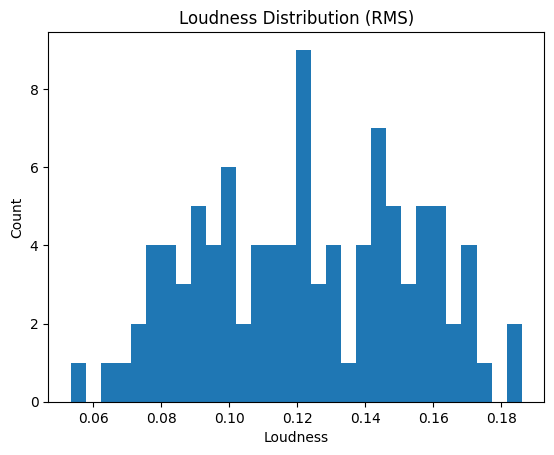

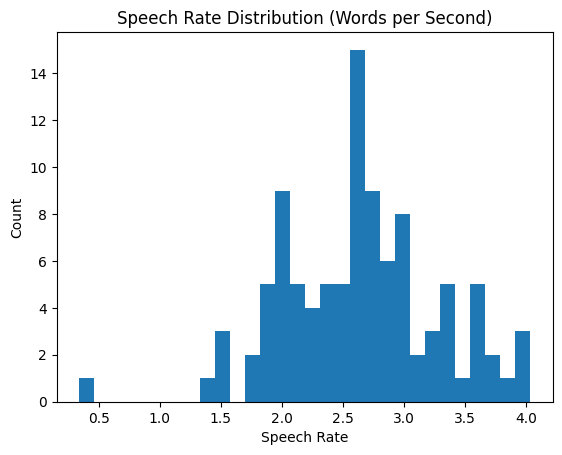

In [17]:
import matplotlib.pyplot as plt

plt.hist(df["loudness"], bins=30)
plt.title("Loudness Distribution (RMS)")
plt.xlabel("Loudness")
plt.ylabel("Count")
plt.show()

plt.hist(df["speech_rate"], bins=30)
plt.title("Speech Rate Distribution (Words per Second)")
plt.xlabel("Speech Rate")
plt.ylabel("Count")
plt.show()